# VOC 분석 (PKL 기반)

- 전처리/형태소분석(Okt)은 이미 완료되어 `merged_*.pkl`을 사용합니다.
- 본 노트북은 **분석 파트만** 재현 가능하게 구성했습니다.


In [7]:
import os
import re
import pickle
from collections import Counter
from itertools import chain
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')
font_path = 'C:/Windows/Fonts/malgun.ttf'

font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rc('axes', unicode_minus=False)
from wordcloud import WordCloud

## 0. PKL 로드

- 아래 `BASE_PATH`만 본인 환경에 맞게 수정합니다.

In [2]:
BASE_PATH = r"C:\Users\legen\Desktop\Lab Project\LG text mining\data_filtered\pickle"

def load_pkl(filename, base_path=BASE_PATH):
    path = os.path.join(base_path, filename)
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일 없음: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)

# 전체(기간 전체) 토큰
merged_styler_ai_content  = load_pkl("merged_styler_ai_content.pkl")
merged_styler_gen_content = load_pkl("merged_styler_gen_content.pkl")
merged_vacuum_ai_content  = load_pkl("merged_vacuum_ai_content.pkl") if os.path.exists(os.path.join(BASE_PATH,"merged_vacuum_ai_content.pkl")) else None
merged_vacuum_gen_content = load_pkl("merged_vacuum_gen_content.pkl")

# (선택) 연도/계절 토큰이 있으면 로드 (없으면 자동 skip)
years = ["2022","2023","2024"]
seasons = ["spring","summer","fall","winter"]

def try_load_to_globals(prefix, keys):
    for k in keys:
        fn = f"{prefix}_{k}_content.pkl"
        full = os.path.join(BASE_PATH, fn)
        if os.path.exists(full):
            globals()[f"{prefix}_{k}_content"] = load_pkl(fn)

for prefix in ["merged_styler_ai", "merged_styler_gen", "merged_vacuum_ai", "merged_vacuum_gen", "merged_robot_gen"]:
    try_load_to_globals(prefix, years)
    try_load_to_globals(prefix, seasons)

DATASET_TOKENS = {
    "styler_ai": merged_styler_ai_content,
    "styler_gen": merged_styler_gen_content,
    "vacuum_ai": merged_vacuum_ai_content,
    "vacuum_gen": merged_vacuum_gen_content,
}
# None 제거
DATASET_TOKENS = {k:v for k,v in DATASET_TOKENS.items() if v is not None}

for k,v in DATASET_TOKENS.items():
    print(k, "docs=", len(v), "| sample_token_len=", len(v[0]) if len(v)>0 else None)

styler_ai docs= 920 | sample_token_len= 596
styler_gen docs= 3425 | sample_token_len= 546
vacuum_ai docs= 946 | sample_token_len= 410
vacuum_gen docs= 4298 | sample_token_len= 241


## 1. 공통 유틸

- 입력은 모두 `List[List[str]]`(문서별 토큰) 입니다.

In [4]:
def flatten_tokens(docs_tokens):
    """List[List[str]] -> List[str]"""
    return list(chain.from_iterable(docs_tokens))

def ngrams_from_tokens(tokens, n=2):
    """List[str] -> List[tuple]"""
    if n <= 1:
        return [(t,) for t in tokens]
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def ngram_counter(docs_tokens, n=2, min_count=2):
    """문서별 토큰에서 n-gram 빈도 Counter 생성"""
    grams = []
    for doc in docs_tokens:
        grams.extend(ngrams_from_tokens(doc, n))
    c = Counter(grams)
    if min_count is None:
        return c
    return Counter({k:v for k,v in c.items() if v >= min_count})

def top_terms_from_docs(docs_tokens, topk=30):
    c = Counter(flatten_tokens(docs_tokens))
    total = sum(c.values()) if c else 0
    rows = []
    for w, cnt in c.most_common(topk):
        rows.append({"term": w, "count": cnt, "share": (cnt/total*100) if total>0 else 0})
    return pd.DataFrame(rows)

def plot_top_terms(df_top, title, topk=30):
    df_plot = df_top.head(topk).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(df_plot["term"], df_plot["count"])
    plt.title(title)
    plt.xlabel("count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def draw_wordcloud(docs_tokens, title, font_path=None, max_words=200):
    text = " ".join(flatten_tokens(docs_tokens))
    wc = WordCloud(
        font_path=font_path, 
        width=1200, height=600, background_color="white", 
        max_words=max_words
    ).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 2. 빈도 분석 (Top30)

,term,count,share
0,옷,2456,0.767968
1,기능,2255,0.705117
2,제품,2111,0.660090
3,스타일러,2014,0.629759
4,에어드레서,1845,0.576914
5,관리,1772,0.554088
6,좋다,1680,0.525320
7,삼성,1511,0.472475
8,가전,1479,0.462469
9,가능하다,1365,0.426823


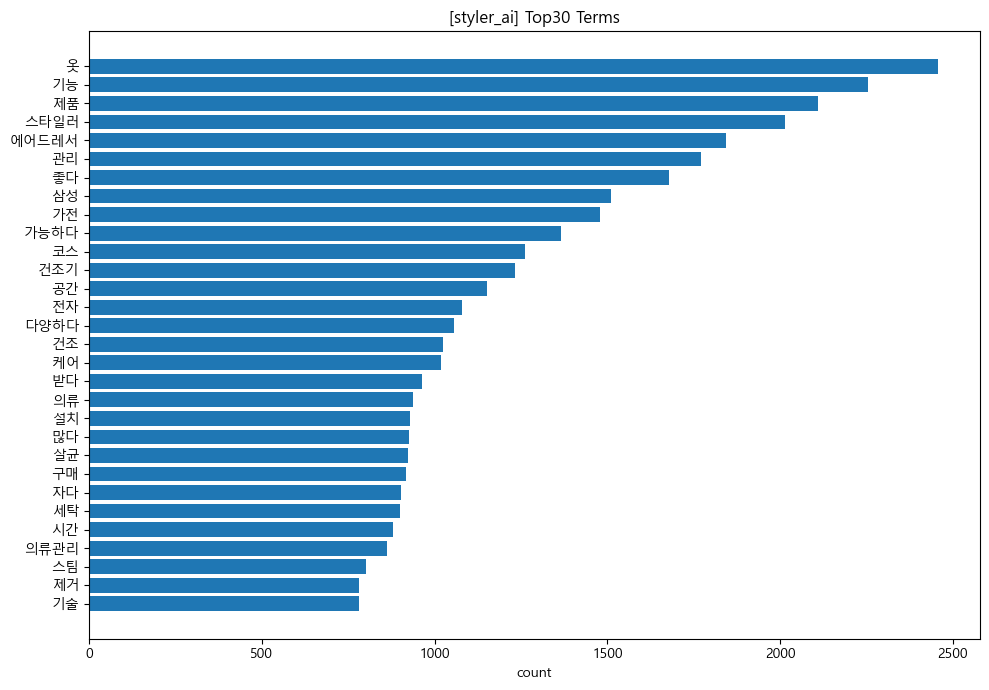

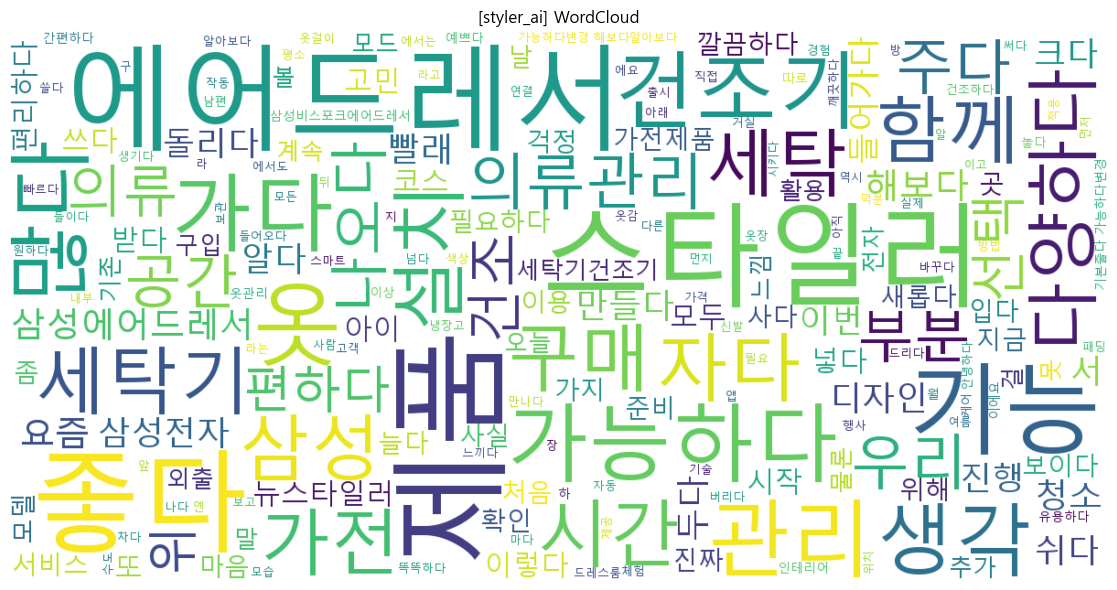

,term,count,share
0,스타일러,15516,1.359287
1,옷,11018,0.965237
2,좋다,9555,0.837070
3,관리,9055,0.793268
4,제품,7566,0.662823
5,의류관리,6767,0.592826
6,기능,6091,0.533605
7,향,5359,0.469478
8,가능하다,5049,0.442320
9,넣다,4851,0.424974


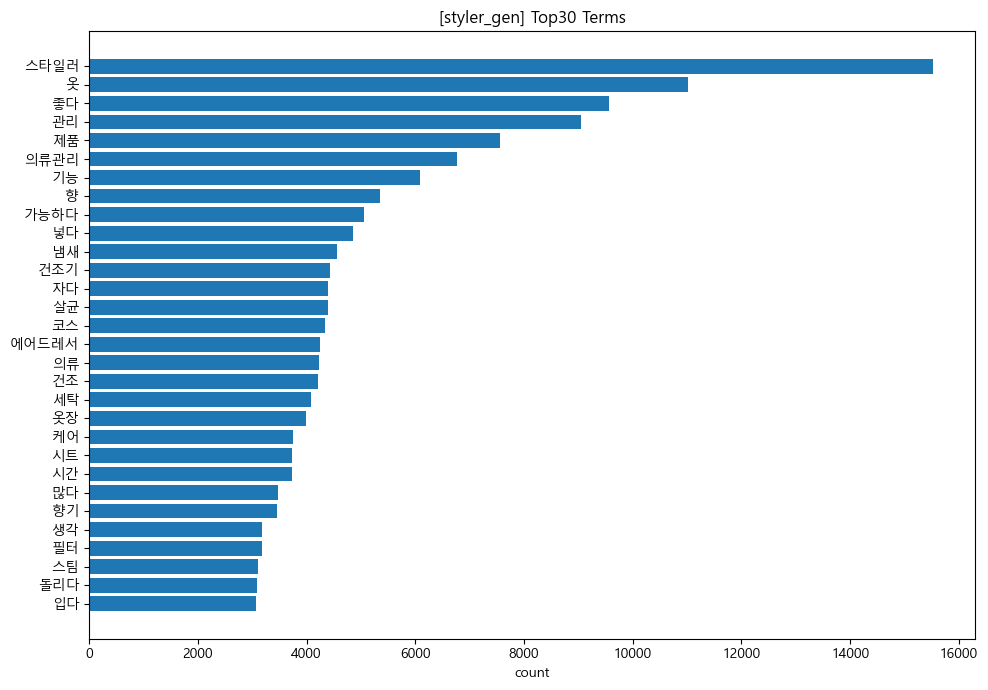

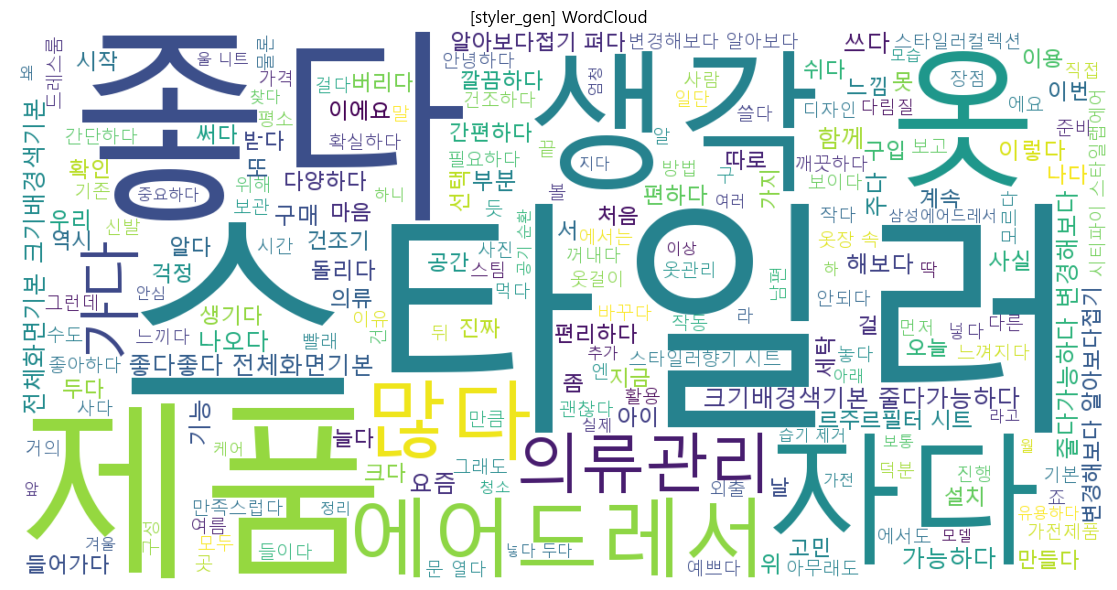

,term,count,share
0,청소,7140,1.728994
1,청소기,3644,0.882416
2,로봇청소기,2682,0.649462
3,제품,2611,0.632269
4,먼지,2454,0.594251
5,기능,2322,0.562286
6,무선청소기,2238,0.541945
7,배터리,2088,0.505622
8,물걸레,2083,0.504411
9,좋다,1903,0.460823


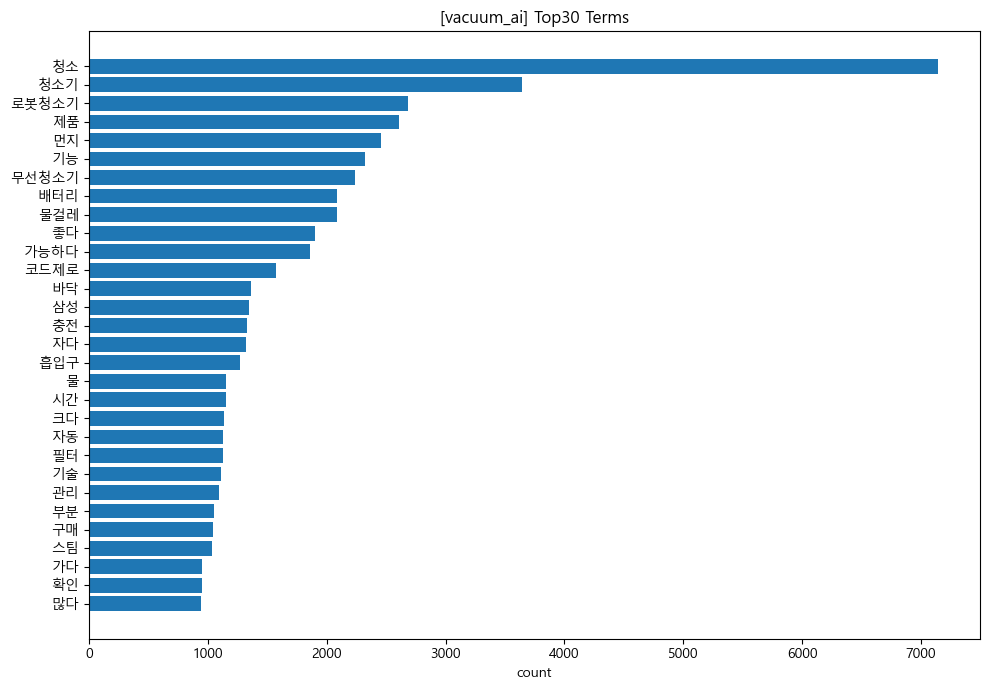

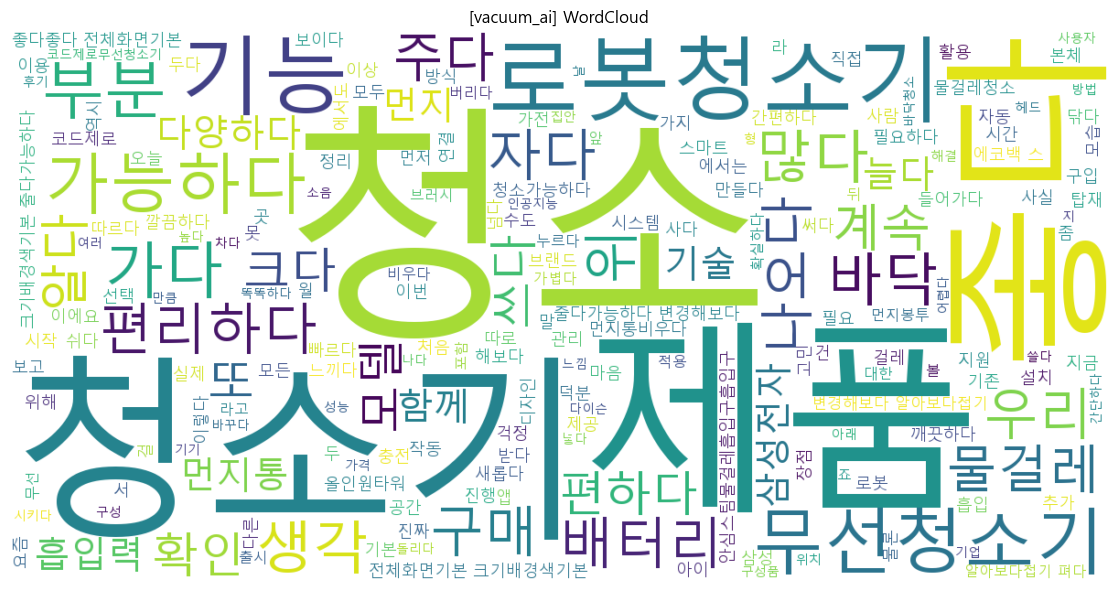

,term,count,share
0,청소,27440,1.948724
1,청소기,26212,1.861514
2,무선청소기,16157,1.147432
3,먼지,11302,0.802641
4,좋다,10468,0.743413
5,제품,10051,0.713798
6,배터리,8062,0.572544
7,충전,7169,0.509125
8,가능하다,7120,0.505646
9,자다,6830,0.485050


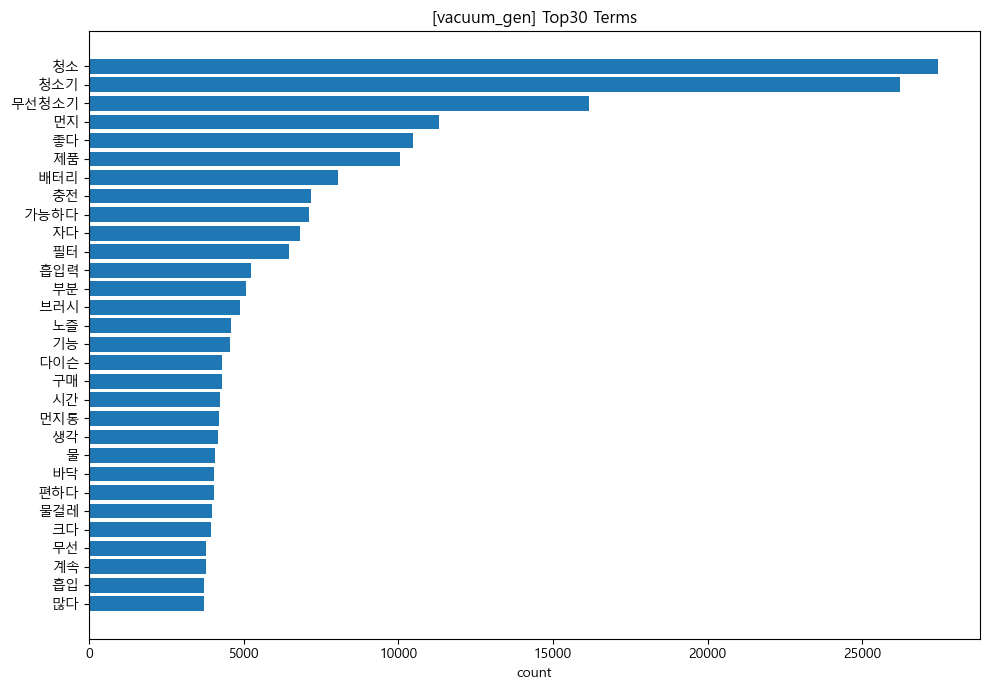

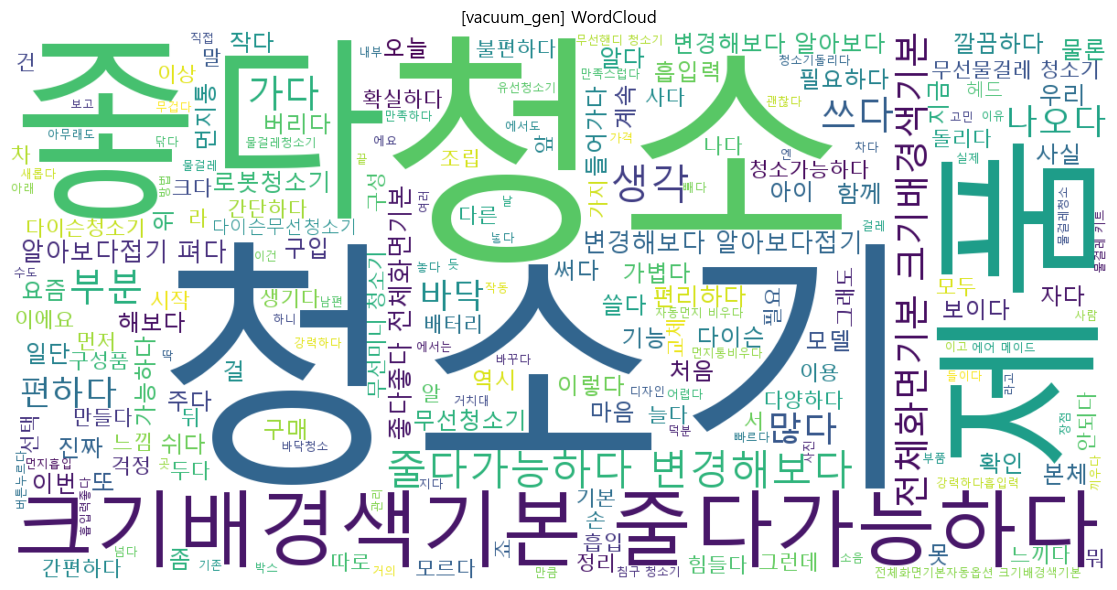

In [8]:
DEFAULT_FONT_PATH = font_path

for name, tokens in DATASET_TOKENS.items():
    top30 = top_terms_from_docs(tokens, topk=30)
    display(top30)
    plot_top_terms(top30, title=f"[{name}] Top30 Terms")
    draw_wordcloud(tokens, title=f"[{name}] WordCloud", font_path=DEFAULT_FONT_PATH, max_words=200)

## 3. N-gram 분석 (Bigram/Trigram)

- `min_count`로 희소 n-gram을 필터링합니다.

In [9]:
def ngram_table(docs_tokens, n=2, topk=30, min_count=3):
    c = ngram_counter(docs_tokens, n=n, min_count=min_count)
    rows = []
    total = sum(c.values()) if c else 0
    for gram, cnt in c.most_common(topk):
        rows.append({"ngram": " ".join(gram), "count": cnt, "share": (cnt/total*100) if total>0 else 0})
    return pd.DataFrame(rows)

for name, tokens in DATASET_TOKENS.items():
    print("====", name, "====")
    display(ngram_table(tokens, n=2, topk=30, min_count=3))
    display(ngram_table(tokens, n=3, topk=30, min_count=2))

==== styler_ai ====


,ngram,count,share
0,기본줄다 가능하다변경,176,0.131030
1,가능하다변경 해보다알아보다,176,0.131030
2,건조구김 제거,115,0.085616
3,해보다알아보다 접기펴다,108,0.080405
4,삼성 스토어,105,0.078172
5,삼성의류 케어가전,103,0.076683
6,버튼 누르다,102,0.075938
7,일체 형,102,0.075938
8,다양하다 기능,101,0.075194
9,탈취 살균,100,0.074449


,ngram,count,share
0,기본줄다 가능하다변경 해보다알아보다,176,0.216751
1,가능하다변경 해보다알아보다 접기펴다,108,0.133007
2,전체화면기본크기배경색 기본줄다 가능하다변경,88,0.108376
3,좋다좋다 전체화면기본자동옵션크기배경색 기본줄다,88,0.108376
4,전체화면기본자동옵션크기배경색 기본줄다 가능하다변경,88,0.108376
5,좋다좋다 전체화면기본크기배경색 기본줄다,81,0.099755
6,상품가격유 무별총 상품후기구매,71,0.087440
7,결과실환경 따르다 다르다,51,0.062809
8,국제 인증 기관,50,0.061577
9,습도 센서 최적건조시간,48,0.059114


==== styler_gen ====


,ngram,count,share
0,크기배경색기본 줄다가능하다,1359,0.215028
1,줄다가능하다 변경해보다,1359,0.215028
2,전체화면기본 크기배경색기본,1231,0.194775
3,좋다좋다 전체화면기본,1180,0.186706
4,르주르필터 시트,822,0.130061
5,변경해보다 알아보다접기,748,0.118353
6,알아보다접기 펴다,744,0.117720
7,변경해보다 알아보다,611,0.096676
8,스타일러향기 시트,575,0.090980
9,옷장 속,418,0.066138


...

,ngram,count,share
0,전체화면기본 크기배경색기본,385,0.224568
1,크기배경색기본 줄다가능하다,385,0.224568
2,줄다가능하다 변경해보다,385,0.224568
3,좋다좋다 전체화면기본,377,0.219902
4,에코백 스,231,0.134741
5,변경해보다 알아보다접기,214,0.124825
6,알아보다접기 펴다,214,0.124825
7,변경해보다 알아보다,171,0.099743
8,기본줄다 가능하다변경,161,0.093910
9,가능하다변경 해보다알아보다,161,0.093910


,ngram,count,share
0,전체화면기본 크기배경색기본 줄다가능하다,385,0.459449
1,크기배경색기본 줄다가능하다 변경해보다,385,0.459449
2,좋다좋다 전체화면기본 크기배경색기본,377,0.449902
3,줄다가능하다 변경해보다 알아보다접기,214,0.255382
4,변경해보다 알아보다접기 펴다,214,0.255382
5,줄다가능하다 변경해보다 알아보다,171,0.204067
6,기본줄다 가능하다변경 해보다알아보다,161,0.192133
7,전체화면기본자동옵션크기배경색 기본줄다 가능하다변경,158,0.188553
8,좋다좋다 전체화면기본자동옵션크기배경색 기본줄다,157,0.187360
9,가능하다변경 해보다알아보다 접기펴다,76,0.090696


==== vacuum_gen ====


,ngram,count,share
0,크기배경색기본 줄다가능하다,2493,0.306673
1,줄다가능하다 변경해보다,2493,0.306673
2,전체화면기본 크기배경색기본,1865,0.229420
3,변경해보다 알아보다접기,1491,0.183413
4,좋다좋다 전체화면기본,1486,0.182798
5,알아보다접기 펴다,1459,0.179477
6,변경해보다 알아보다,1002,0.123260
7,무선물걸레 청소기,841,0.103454
8,무선미니 청소기,653,0.080328
9,전체화면기본자동옵션 크기배경색기본,628,0.077252


,ngram,count,share
0,크기배경색기본 줄다가능하다 변경해보다,2493,0.730363
1,전체화면기본 크기배경색기본 줄다가능하다,1865,0.546381
2,줄다가능하다 변경해보다 알아보다접기,1491,0.436812
3,좋다좋다 전체화면기본 크기배경색기본,1486,0.435347
4,변경해보다 알아보다접기 펴다,1459,0.427437
5,줄다가능하다 변경해보다 알아보다,1002,0.293552
6,전체화면기본자동옵션 크기배경색기본 줄다가능하다,628,0.183982
7,좋다좋다 전체화면기본자동옵션 크기배경색기본,474,0.138866
8,기본줄다 가능하다변경 해보다알아보다,453,0.132713
9,좋다전체화면 기본크기배경색 기본줄다,338,0.099022


## 4. (2.1) VOC → 구매 여정(Funnel) 연결

- 키워드 사전을 기준으로 토큰 매칭 빈도를 집계합니다.
- **사전(`FUNNEL_DICT`)은 프로젝트 결과에 맞게 보강**하는 것을 권장합니다.

,stage,matched_docs,matched_share(%),top_keywords
1,고려(Consideration),661,71.847826,"기능, 모델, 용량, 소음, 무게, 차이, 스펙, 흡입"
2,결정(Decision),589,64.021739,"구매, 설치, 가격, 할인, 결제, 쿠폰, 교환, 환불"
0,인지(Awareness),544,59.130435,"추천, 후기, 리뷰, 브랜드, 검색, 블로그, 유튜브"
3,사용/유지(Use & Retain),522,56.739130,"관리, 청소, 만족, 고장, 편리, 불편"


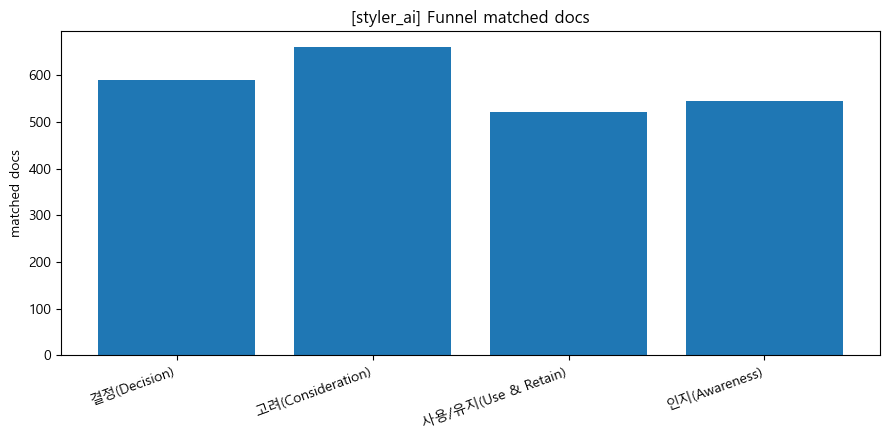

,stage,matched_docs,matched_share(%),top_keywords
1,고려(Consideration),2284,66.686131,"기능, 소음, 모델, 용량, 차이, 무게, 스펙, 흡입"
3,사용/유지(Use & Retain),2228,65.051095,"관리, 청소, 만족, 고장, 편리, 불편"
0,인지(Awareness),2097,61.226277,"추천, 후기, 브랜드, 리뷰, 검색, 블로그, 유튜브"
2,결정(Decision),2077,60.642336,"구매, 설치, 가격, 할인, 결제, 쿠폰, 교환, 환불"


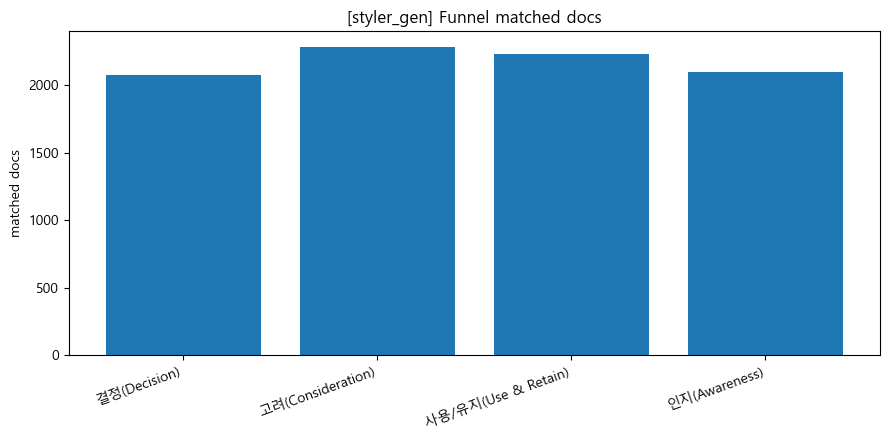

,stage,matched_docs,matched_share(%),top_keywords
3,사용/유지(Use & Retain),830,87.737844,"청소, 관리, 고장, 만족, 편리, 불편"
1,고려(Consideration),801,84.672304,"기능, 흡입, 모델, 무게, 소음, 용량, 차이, 스펙"
0,인지(Awareness),650,68.710359,"추천, 후기, 리뷰, 브랜드, 검색, 블로그, 유튜브"
2,결정(Decision),601,63.530655,"구매, 가격, 설치, 할인, 결제, 쿠폰, 교환, 환불"


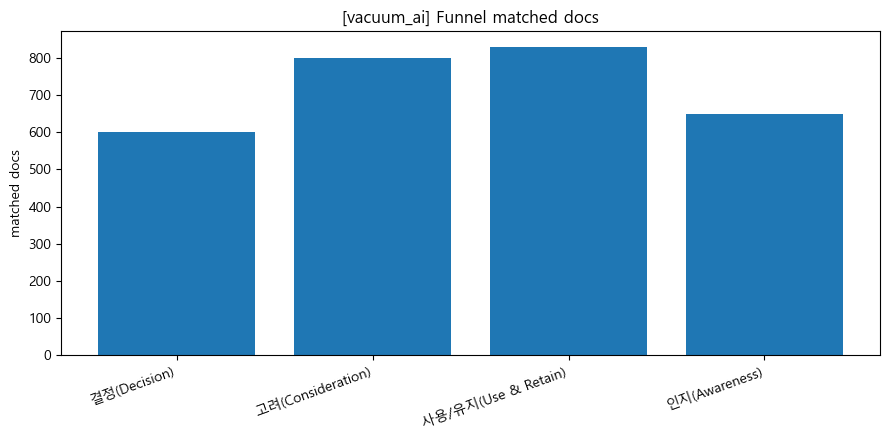

,stage,matched_docs,matched_share(%),top_keywords
3,사용/유지(Use & Retain),3825,88.994881,"청소, 관리, 고장, 만족, 편리, 불편"
1,고려(Consideration),3324,77.338297,"기능, 흡입, 무게, 소음, 모델, 용량, 차이, 스펙"
0,인지(Awareness),2774,64.541647,"후기, 추천, 브랜드, 리뷰, 검색, 블로그, 유튜브"
2,결정(Decision),2648,61.610051,"구매, 가격, 할인, 설치, 교환, 쿠폰, 결제, 환불"


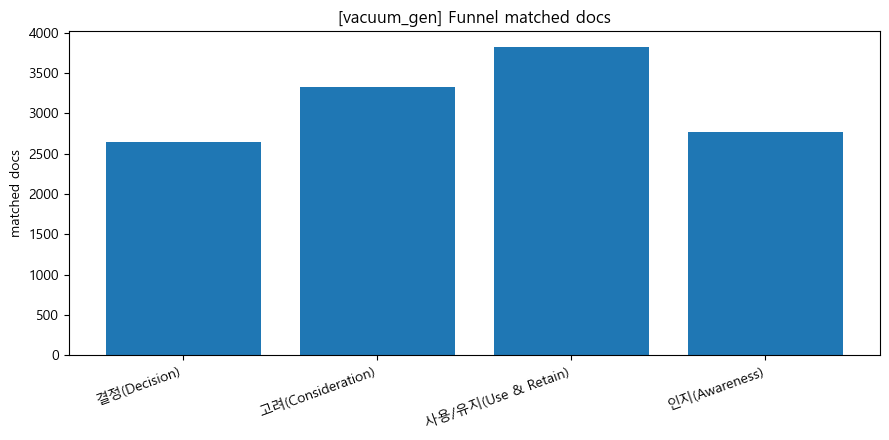

In [10]:
# 퍼널 키워드 사전 (초기 템플릿) - 필요 시 보강
FUNNEL_DICT = {
    "인지(Awareness)": [
        "검색", "광고", "추천", "유튜브", "블로그", "후기", "리뷰", "브랜드"
    ],
    "고려(Consideration)": [
        "비교", "차이", "모델", "스펙", "기능", "흡입", "소음", "무게", "용량", "AI"
    ],
    "결정(Decision)": [
        "가격", "할인", "쿠폰", "구매", "결제", "배송", "설치", "AS", "환불", "교환"
    ],
    "사용/유지(Use & Retain)": [
        "만족", "편함", "편리", "불편", "고장", "내구", "청소", "관리", "재구매"
    ],
}

def funnel_score_docs(docs_tokens, funnel_dict=FUNNEL_DICT):
    # stage별 키워드 set
    stage_sets = {s:set(ws) for s,ws in funnel_dict.items()}
    stage_counts = Counter()
    stage_top_hits = {s: Counter() for s in funnel_dict.keys()}

    for doc in docs_tokens:
        doc_set = set(doc)
        for stage, wset in stage_sets.items():
            hits = doc_set & wset
            if hits:
                stage_counts[stage] += 1  # 문서 단위 매칭(문서 수 기준)
                stage_top_hits[stage].update(hits)

    total_docs = len(docs_tokens)
    rows = []
    for stage in funnel_dict.keys():
        doc_cnt = stage_counts.get(stage, 0)
        rows.append({
            "stage": stage,
            "matched_docs": doc_cnt,
            "matched_share(%)": (doc_cnt/total_docs*100) if total_docs>0 else 0,
            "top_keywords": ", ".join([w for w,_ in stage_top_hits[stage].most_common(10)])
        })
    return pd.DataFrame(rows).sort_values("matched_docs", ascending=False)

def plot_funnel(df_funnel, title):
    plt.figure(figsize=(9, 4.5))
    plt.bar(df_funnel["stage"], df_funnel["matched_docs"])
    plt.title(title)
    plt.ylabel("matched docs")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

for name, tokens in DATASET_TOKENS.items():
    df_f = funnel_score_docs(tokens, FUNNEL_DICT)
    display(df_f)
    plot_funnel(df_f.sort_values("stage"), title=f"[{name}] Funnel matched docs")

## 5. (2.2) 전환 촉진 VOC vs 전환 저해 VOC

- 촉진/저해 키워드 사전으로 문서를 약식 라벨링 후,
  각 그룹에서 많이 등장한 토큰 Top10을 비교합니다.
- **사전(`CONV_DICT`)은 프로젝트 결과에 맞게 보강**하는 것을 권장합니다.

In [11]:
CONV_DICT = {
    "촉진(Driver)": [
        "편하다","편리","만족","좋다","좋음","추천","강추","효과","깔끔","시간","절약","자동","AI"
    ],
    "저해(Barrier)": [
        "비싸","가격","소음","무겁","불편","고장","AS","수리","오류","번거","냄새","먼지","약함","불만"
    ]
}

def label_docs_by_keyword(docs_tokens, keywords):
    keyset = set(keywords)
    labels = []
    for doc in docs_tokens:
        doc_set = set(doc)
        labels.append(len(doc_set & keyset) > 0)
    return np.array(labels, dtype=bool)

def top_terms_in_group(docs_tokens, mask, topk=10):
    selected = [docs_tokens[i] for i in range(len(docs_tokens)) if mask[i]]
    c = Counter(flatten_tokens(selected))
    rows = [{"term":w, "count":cnt} for w,cnt in c.most_common(topk)]
    return pd.DataFrame(rows), len(selected)

for name, tokens in DATASET_TOKENS.items():
    print("====", name, "====")
    mask_driver = label_docs_by_keyword(tokens, CONV_DICT["촉진(Driver)"])
    mask_barrier = label_docs_by_keyword(tokens, CONV_DICT["저해(Barrier)"])

    df_driver, n_driver = top_terms_in_group(tokens, mask_driver, topk=10)
    df_barrier, n_barrier = top_terms_in_group(tokens, mask_barrier, topk=10)

    summary = pd.DataFrame([{
        "dataset": name,
        "total_docs": len(tokens),
        "driver_docs": int(n_driver),
        "driver_share(%)": (n_driver/len(tokens)*100) if len(tokens)>0 else 0,
        "barrier_docs": int(n_barrier),
        "barrier_share(%)": (n_barrier/len(tokens)*100) if len(tokens)>0 else 0,
    }])
    display(summary)
    print("[촉진 Top10]")
    display(df_driver)
    print("[저해 Top10]")
    display(df_barrier)

==== styler_ai ====


,dataset,total_docs,driver_docs,driver_share(%),barrier_docs,barrier_share(%)
0,styler_ai,920,799,86.847826,554,60.217391


[촉진 Top10]


,term,count
0,옷,2384
1,기능,2174
2,제품,1980
3,스타일러,1926
4,에어드레서,1717
5,관리,1701
6,좋다,1680
7,삼성,1372
8,가전,1313
9,가능하다,1300


[저해 Top10]


...

,dataset,total_docs,driver_docs,driver_share(%),barrier_docs,barrier_share(%)
0,vacuum_gen,4298,3931,91.461145,3661,85.179153


[촉진 Top10]


,term,count
0,청소,26625
1,청소기,25139
2,무선청소기,15550
3,먼지,10982
4,좋다,10468
5,제품,9679
6,배터리,7496
7,충전,6912
8,가능하다,6904
9,자다,6480


[저해 Top10]


,term,count
0,청소,25533
1,청소기,23978
2,무선청소기,14799
3,먼지,11302
4,좋다,9624
5,제품,9079
6,배터리,7122
7,가능하다,6629
8,충전,6467
9,필터,6249


In [12]:
summary_rows = []

for dataset in ["styler_ai", "styler_gen", "vacuum_ai", "vacuum_gen"]:
    funnel = funnel_result[dataset]      # stage, matched_share
    conv   = conv_result[dataset]         # driver_share, barrier_share
    
    summary_rows.append({
        "제품군": "Styler" if "styler" in dataset else "Vacuum",
        "모델": "AI" if "ai" in dataset else "일반",
        "주요 퍼널": funnel.sort_values("matched_share(%)", ascending=False).iloc[0]["stage"],
        "촉진 비중": conv["driver_share(%)"].iloc[0],
        "저해 비중": conv["barrier_share(%)"].iloc[0]
    })

summary_df = pd.DataFrame(summary_rows)


NameError: name 'funnel_result' is not defined